In [ ]:
!pip install lifelines

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
sns.set(style="whitegrid")

In [ ]:
file_path = "/content/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(file_path)

print(df.head())
print("Jumlah baris dan kolom:", df.shape)

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [ ]:
print("infromasi dataset:")
print(df.info())

print("\nnama kolom:")
print(df.columns)

print("\nstatistik deskriptif:")
print(df.describe())

infromasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB

pilih bariabel target

In [ ]:
selected_columns = [
    "age",
    "serum_creatinine",
    "ejection_fraction",
    "time",
    "DEATH_EVENT"
]

survival_df = df[selected_columns].copy()
print(survival_df.head())

    age  serum_creatinine  ejection_fraction  time  DEATH_EVENT
0  75.0               1.9                 20     4            1
1  55.0               1.1                 38     6            1
2  65.0               1.3                 20     7            1
3  50.0               1.9                 20     7            1
4  65.0               2.7                 20     8            1


distrubusi status kematian

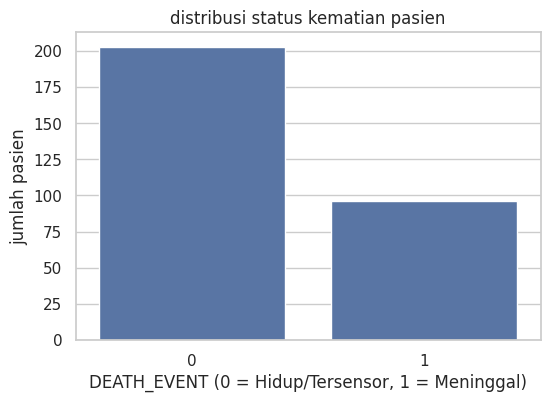

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=survival_df, x="DEATH_EVENT")
plt.title("distribusi status kematian pasien")
plt.xlabel("DEATH_EVENT (0 = Hidup/Tersensor, 1 = Meninggal)")
plt.ylabel("jumlah pasien")
plt.show()

print(survival_df["DEATH_EVENT"].value_counts())

distribusi variabel medis utama

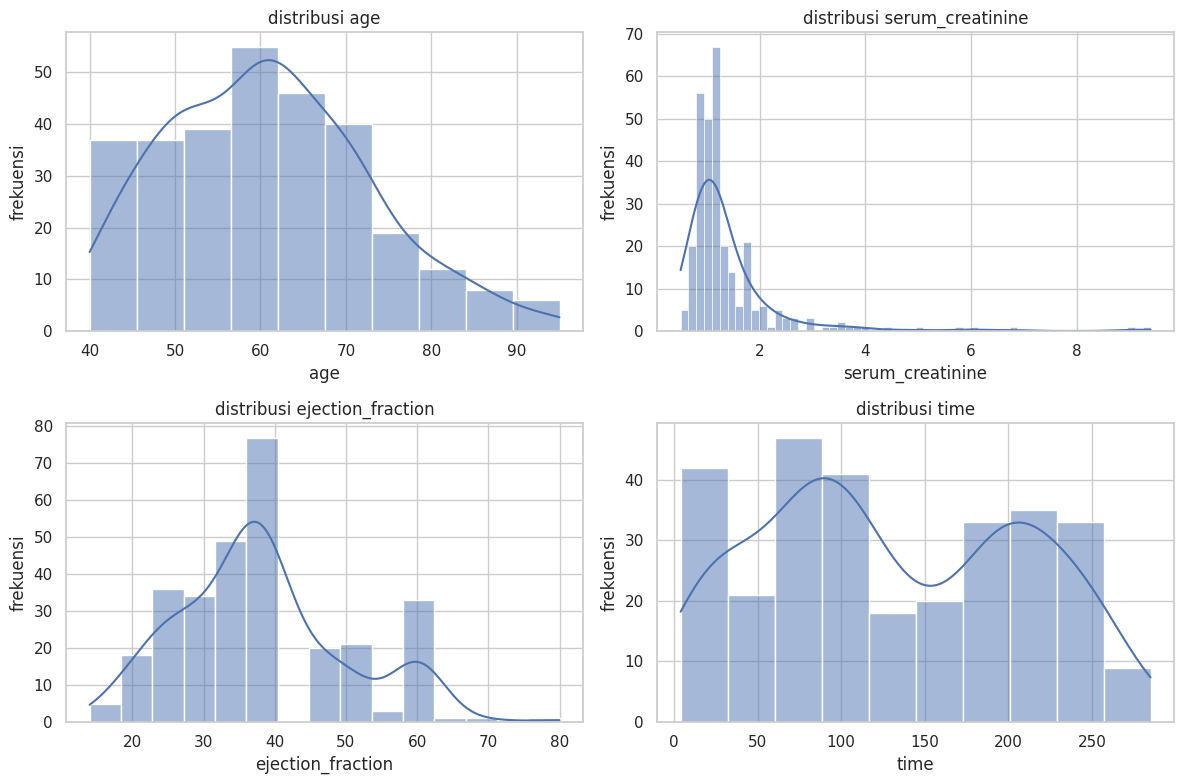

In [ ]:
numeric_features = ["age", "serum_creatinine", "ejection_fraction", "time"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(survival_df[col], kde=True)
    plt.title(f"distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("frekuensi")

plt.tight_layout()
plt.show()

outlier boxplot

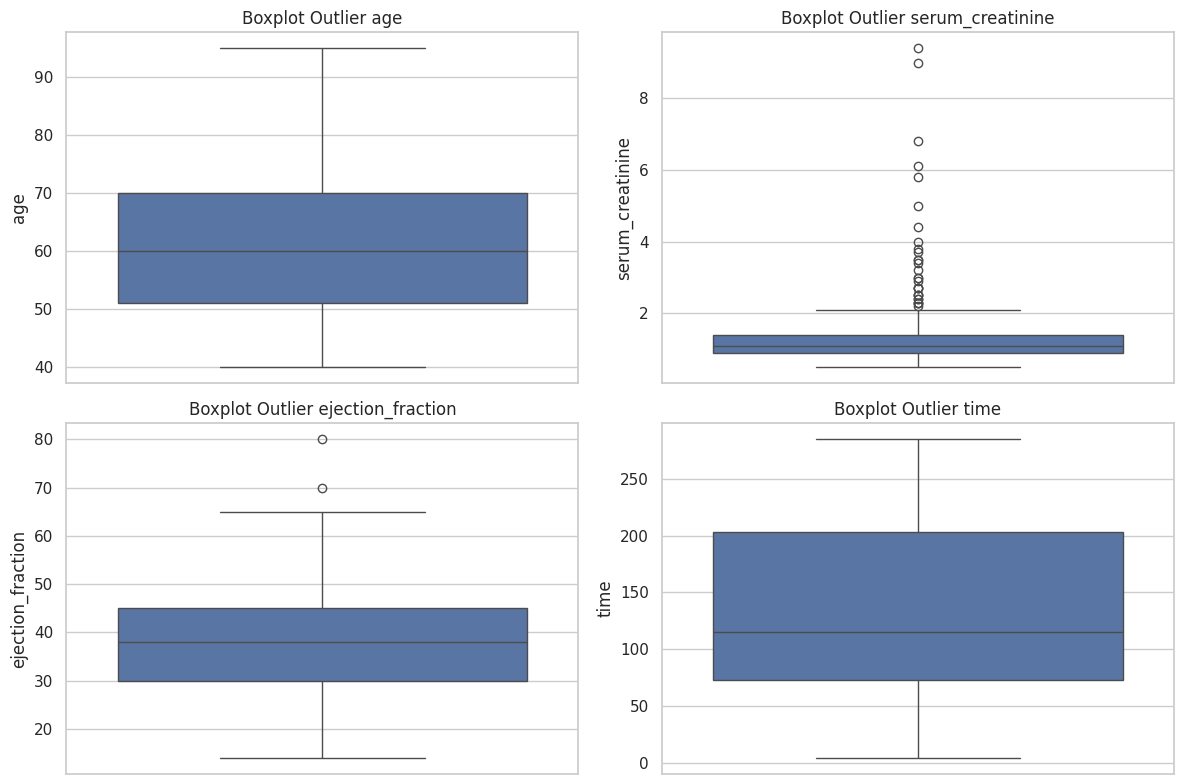

In [ ]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=survival_df[col])
    plt.title(f"Boxplot Outlier {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

metode IQR

In [ ]:
def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return lower_bound, upper_bound, len(outliers)

outlier_summary = []

for col in numeric_features:
    lower, upper, total_outlier = detect_outlier_iqr(survival_df, col)
    outlier_summary.append({
        "Variabel": col,
        "Batas Bawah": lower,
        "Batas Atas": upper,
        "Jumlah Outlier": total_outlier
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

            Variabel  Batas Bawah  Batas Atas  Jumlah Outlier
0                age        22.50       98.50               0
1   serum_creatinine         0.15        2.15              29
2  ejection_fraction         7.50       67.50               2
3               time      -122.00      398.00               0


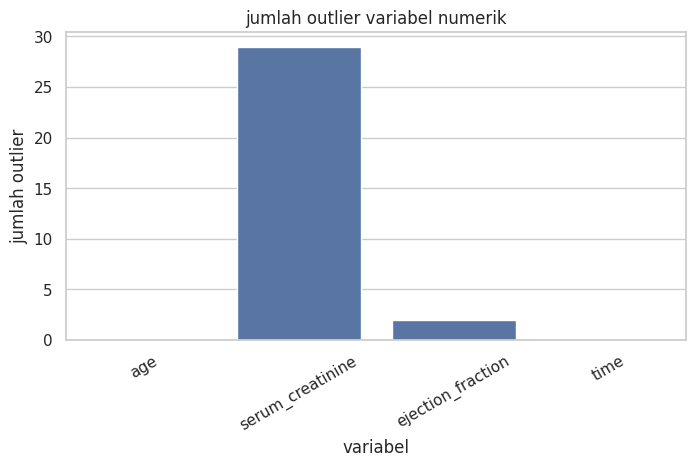

Outlier pada data medis tidak langsung dihapus karena nilai ekstrem dapat menggambarkan kondisi klinis pasien yang memang berisiko tinggi. 
Oleh karena itu, outlier hanya dianalisis dan divisualisasikan, bukan dihapus secara otomatis, agar informasi medis penting tidak hilang.


In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=outlier_df, x="Variabel", y="Jumlah Outlier")
plt.title("jumlah outlier variabel numerik")
plt.xlabel("variabel")
plt.ylabel("jumlah outlier")
plt.xticks(rotation=30)
plt.show()

print("Outlier pada data medis tidak langsung dihapus karena nilai ekstrem dapat menggambarkan kondisi klinis pasien yang memang berisiko tinggi. ")
print ("Oleh karena itu, outlier hanya dianalisis dan divisualisasikan, bukan dihapus secara otomatis, agar informasi medis penting tidak hilang.")

korelasi variabel

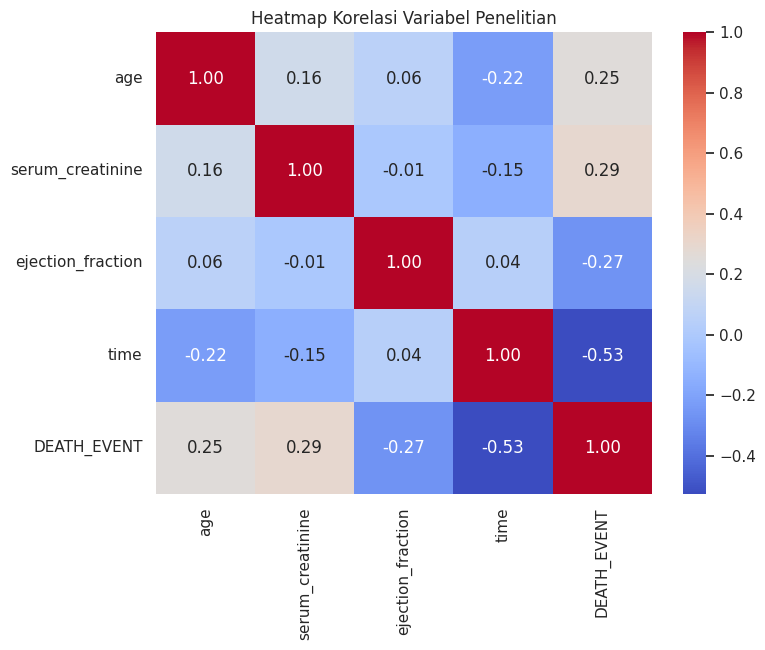

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    survival_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Heatmap Korelasi Variabel Penelitian")
plt.show()

model cox proportional hazards

In [ ]:
model_df = survival_df.copy()

model_df["age_10_years"] = model_df["age"] / 10
model_df["ejection_fraction_5_percent"] = model_df["ejection_fraction"] / 5

cox_df = model_df[[
    "age_10_years",
    "serum_creatinine",
    "ejection_fraction_5_percent",
    "time",
    "DEATH_EVENT"
]].copy()

print(cox_df.head())

   age_10_years  serum_creatinine  ejection_fraction_5_percent  time  \
0           7.5               1.9                          4.0     4   
1           5.5               1.1                          7.6     6   
2           6.5               1.3                          4.0     7   
3           5.0               1.9                          4.0     7   
4           6.5               2.7                          4.0     8   

   DEATH_EVENT  
0            1  
1            1  
2            1  
3            1  
4            1  


In [ ]:
cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="time",
    event_col="DEATH_EVENT"
)

hasil_cox = cph.summary[[
    "coef",
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].copy()

hasil_cox = hasil_cox.rename(columns={
    "coef": "Koefisien",
    "exp(coef)": "Hazard Ratio",
    "exp(coef) lower 95%": "CI 95% Bawah",
    "exp(coef) upper 95%": "CI 95% Atas",
    "p": "P-value"
})

hasil_cox = hasil_cox.round(4)

print("tabel hazard ratio faktor medis terhadap resiko kematian:")
print(hasil_cox)

tabel hazard ratio faktor medis terhadap resiko kematian:
                             Koefisien  Hazard Ratio  CI 95% Bawah  \
covariate                                                            
age_10_years                    0.4416        1.5553        1.3050   
serum_creatinine                0.3578        1.4302        1.2512   
ejection_fraction_5_percent    -0.2444        0.7832        0.7089   

                             CI 95% Atas  P-value  
covariate                                          
age_10_years                      1.8535      0.0  
serum_creatinine                  1.6349      0.0  
ejection_fraction_5_percent       0.8653      0.0  


visualisasi hazard ratio dengan confidence interval

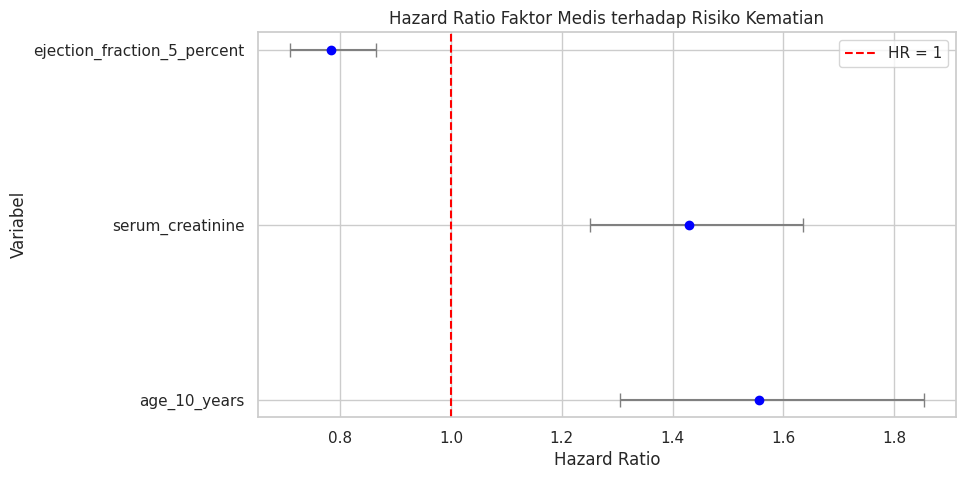

In [ ]:
plot_df = hasil_cox.reset_index()
plot_df = plot_df.rename(columns={"covariate": "Variabel"})

plt.figure(figsize=(9, 5))

plt.errorbar(
    x=plot_df["Hazard Ratio"],
    y=plot_df["Variabel"],
    xerr=[
        plot_df["Hazard Ratio"] - plot_df["CI 95% Bawah"],
        plot_df["CI 95% Atas"] - plot_df["Hazard Ratio"]
    ],
    fmt="o",
    color="blue",
    ecolor="gray",
    capsize=5
)

plt.axvline(x=1, color="red", linestyle="--", label="HR = 1")
plt.title("Hazard Ratio Faktor Medis terhadap Risiko Kematian")
plt.xlabel("Hazard Ratio")
plt.ylabel("Variabel")
plt.legend()
plt.grid(True)
plt.show()

# Analisis Survival Tambahan


In [ ]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Data survival lengkap
survival_lengkap = df.copy()

# Membuat kategori ejection fraction
# EF rendah diberi nilai 1 jika ejection_fraction < 40%, dan 0 jika >= 40%
survival_lengkap["EF_rendah"] = np.where(
    survival_lengkap["ejection_fraction"] < 40,
    1,
    0
)

survival_lengkap["kategori_EF"] = np.where(
    survival_lengkap["ejection_fraction"] < 40,
    "EF Rendah (<40%)",
    "EF Tinggi (>=40%)"
)

# Label diabetes agar grafik lebih mudah dibaca
survival_lengkap["kategori_diabetes"] = survival_lengkap["diabetes"].map({
    0: "Tidak Diabetes",
    1: "Diabetes"
})

print(survival_lengkap[[
    "time", "DEATH_EVENT", "ejection_fraction", "EF_rendah",
    "kategori_EF", "diabetes", "kategori_diabetes"
]].head())

print("\nJumlah pasien berdasarkan kategori EF:")
print(survival_lengkap["kategori_EF"].value_counts())

print("\nJumlah pasien berdasarkan diabetes:")
print(survival_lengkap["kategori_diabetes"].value_counts())

   time  DEATH_EVENT  ejection_fraction  EF_rendah       kategori_EF  \
0     4            1                 20          1  EF Rendah (<40%)   
1     6            1                 38          1  EF Rendah (<40%)   
2     7            1                 20          1  EF Rendah (<40%)   
3     7            1                 20          1  EF Rendah (<40%)   
4     8            1                 20          1  EF Rendah (<40%)   

   diabetes kategori_diabetes  
0         0    Tidak Diabetes  
1         0    Tidak Diabetes  
2         0    Tidak Diabetes  
3         0    Tidak Diabetes  
4         1          Diabetes  

Jumlah pasien berdasarkan kategori EF:
kategori_EF
EF Rendah (<40%)     182
EF Tinggi (>=40%)    117
Name: count, dtype: int64

Jumlah pasien berdasarkan diabetes:
kategori_diabetes
Tidak Diabetes    174
Diabetes          125
Name: count, dtype: int64


## Estimasi Kurva Survival Kaplan-Meier Keseluruhan

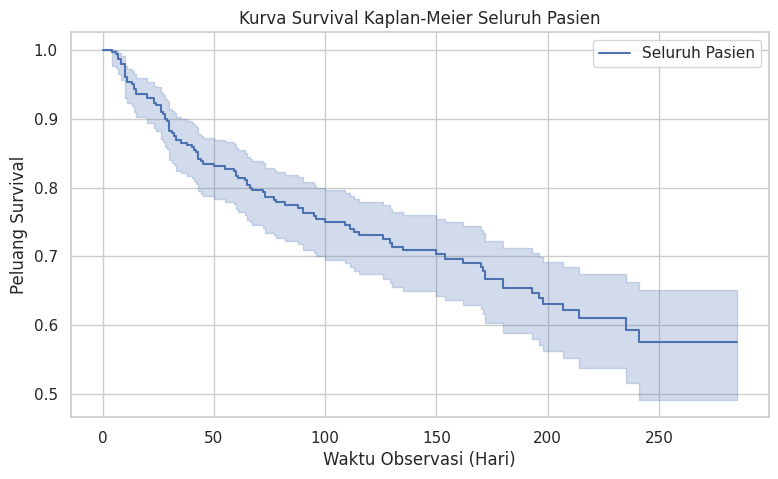

Peluang survival pada beberapa waktu observasi:
   Hari  Peluang Survival
0    30            0.8823
1    60            0.8172
2    90            0.7627
3   120            0.7305
4   180            0.6543
5   240            0.5937
6   280            0.5757


In [ ]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_lengkap["time"],
    event_observed=survival_lengkap["DEATH_EVENT"],
    label="Seluruh Pasien"
)

plt.figure(figsize=(9, 5))
kmf.plot_survival_function(ci_show=True)
plt.title("Kurva Survival Kaplan-Meier Seluruh Pasien")
plt.xlabel("Waktu Observasi (Hari)")
plt.ylabel("Peluang Survival")
plt.grid(True)
plt.show()

# Menampilkan tabel peluang survival pada beberapa waktu tertentu
timeline = [30, 60, 90, 120, 180, 240, 280]
survival_prob = kmf.survival_function_at_times(timeline)

survival_table = pd.DataFrame({
    "Hari": timeline,
    "Peluang Survival": survival_prob.values
})

print("Peluang survival pada beberapa waktu observasi:")
print(survival_table.round(4))

## Kaplan-Meier Plot Berdasarkan Diabetes

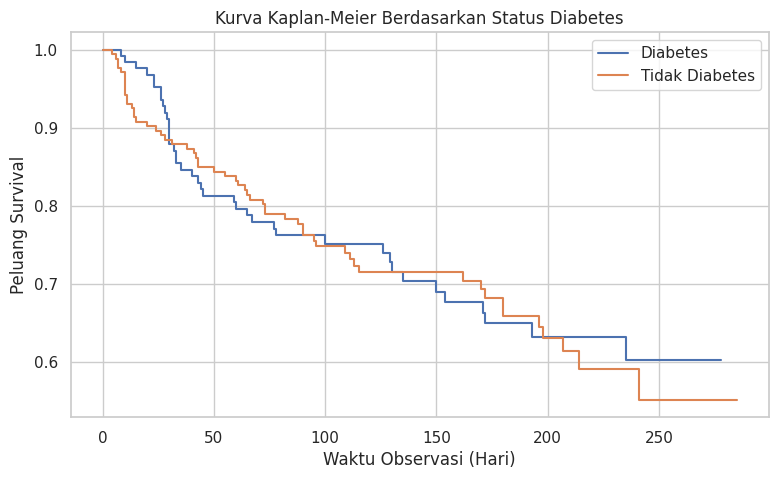

In [ ]:
plt.figure(figsize=(9, 5))

for label, data_kelompok in survival_lengkap.groupby("kategori_diabetes"):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=data_kelompok["time"],
        event_observed=data_kelompok["DEATH_EVENT"],
        label=label
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kurva Kaplan-Meier Berdasarkan Status Diabetes")
plt.xlabel("Waktu Observasi (Hari)")
plt.ylabel("Peluang Survival")
plt.grid(True)
plt.show()

## Kaplan-Meier Plot Berdasarkan Kategori Ejection Fraction

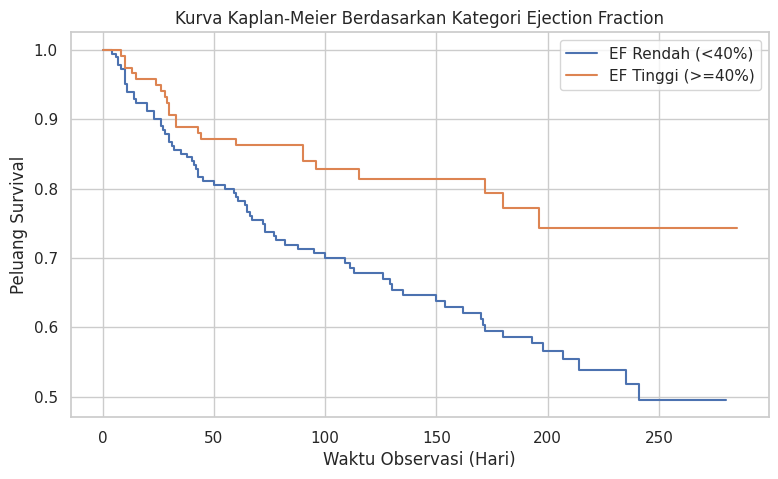

In [ ]:
plt.figure(figsize=(9, 5))

for label, data_kelompok in survival_lengkap.groupby("kategori_EF"):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=data_kelompok["time"],
        event_observed=data_kelompok["DEATH_EVENT"],
        label=label
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kurva Kaplan-Meier Berdasarkan Kategori Ejection Fraction")
plt.xlabel("Waktu Observasi (Hari)")
plt.ylabel("Peluang Survival")
plt.grid(True)
plt.show()

## Uji Log-Rank


In [ ]:
def uji_logrank_dua_kelompok(data, kolom_grup, nama_uji):
    grup_unik = data[kolom_grup].dropna().unique()

    if len(grup_unik) != 2:
        print(f"{nama_uji}: jumlah kelompok harus 2.")
        return None

    grup_1, grup_2 = grup_unik[0], grup_unik[1]

    data_1 = data[data[kolom_grup] == grup_1]
    data_2 = data[data[kolom_grup] == grup_2]

    hasil = logrank_test(
        durations_A=data_1["time"],
        durations_B=data_2["time"],
        event_observed_A=data_1["DEATH_EVENT"],
        event_observed_B=data_2["DEATH_EVENT"]
    )

    print("=" * 60)
    print(nama_uji)
    print(f"Kelompok 1: {grup_1} | n = {len(data_1)}")
    print(f"Kelompok 2: {grup_2} | n = {len(data_2)}")
    print(f"Statistik Log-Rank: {hasil.test_statistic:.4f}")
    print(f"P-value: {hasil.p_value:.4f}")

    if hasil.p_value < 0.05:
        print("Keputusan: Tolak H0")
        print("Interpretasi: terdapat perbedaan kurva survival yang signifikan antar kelompok.")
    else:
        print("Keputusan: Gagal tolak H0")
        print("Interpretasi: tidak terdapat perbedaan kurva survival yang signifikan antar kelompok.")

    return hasil

hasil_logrank_diabetes = uji_logrank_dua_kelompok(
    survival_lengkap,
    "kategori_diabetes",
    "Uji Log-Rank Berdasarkan Status Diabetes"
)

hasil_logrank_ef = uji_logrank_dua_kelompok(
    survival_lengkap,
    "kategori_EF",
    "Uji Log-Rank Berdasarkan Kategori Ejection Fraction"
)

Uji Log-Rank Berdasarkan Status Diabetes
Kelompok 1: Tidak Diabetes | n = 174
Kelompok 2: Diabetes | n = 125
Statistik Log-Rank: 0.0405
P-value: 0.8405
Keputusan: Gagal tolak H0
Interpretasi: tidak terdapat perbedaan kurva survival yang signifikan antar kelompok.
Uji Log-Rank Berdasarkan Kategori Ejection Fraction
Kelompok 1: EF Rendah (<40%) | n = 182
Kelompok 2: EF Tinggi (>=40%) | n = 117
Statistik Log-Rank: 9.4696
P-value: 0.0021
Keputusan: Tolak H0
Interpretasi: terdapat perbedaan kurva survival yang signifikan antar kelompok.


## Pemodelan Cox Proportional Hazard


In [ ]:
# Transformasi agar interpretasi lebih mudah
cox_lengkap = survival_lengkap.copy()

cox_lengkap["age_10_years"] = cox_lengkap["age"] / 10
cox_lengkap["creatinine_phosphokinase_1000"] = cox_lengkap["creatinine_phosphokinase"] / 1000
cox_lengkap["platelets_100k"] = cox_lengkap["platelets"] / 100000

# Model Cox memakai variabel numerik dan kategori biner
# EF_rendah dipakai sebagai kategori: 1 = EF rendah, 0 = EF tinggi
cox_df_lengkap = cox_lengkap[[
    "age_10_years",
    "anaemia",
    "creatinine_phosphokinase_1000",
    "diabetes",
    "EF_rendah",
    "high_blood_pressure",
    "platelets_100k",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking",
    "time",
    "DEATH_EVENT"
]].dropna()

cph_full = CoxPHFitter()

cph_full.fit(
    cox_df_lengkap,
    duration_col="time",
    event_col="DEATH_EVENT"
)

hasil_cox_full = cph_full.summary[[
    "coef",
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "z",
    "p"
]].copy()

hasil_cox_full = hasil_cox_full.rename(columns={
    "coef": "Koefisien",
    "exp(coef)": "Hazard Ratio",
    "exp(coef) lower 95%": "CI 95% Bawah",
    "exp(coef) upper 95%": "CI 95% Atas",
    "z": "Wald z",
    "p": "P-value"
})

hasil_cox_full = hasil_cox_full.round(4)

print("Tabel Hasil Cox Proportional Hazard:")
print(hasil_cox_full)

print("\nRingkasan model dari lifelines:")
cph_full.print_summary()

Tabel Hasil Cox Proportional Hazard:
                               Koefisien  Hazard Ratio  CI 95% Bawah  \
covariate                                                              
age_10_years                      0.4299        1.5370        1.2873   
anaemia                           0.4913        1.6345        1.0630   
creatinine_phosphokinase_1000     0.1930        1.2129        0.9970   
diabetes                          0.0794        1.0827        0.6994   
EF_rendah                         0.8046        2.2357        1.3669   
high_blood_pressure               0.4794        1.6151        1.0569   
platelets_100k                   -0.0474        0.9537        0.7649   
serum_creatinine                  0.2731        1.3140        1.1587   
serum_sodium                     -0.0568        0.9448        0.9056   
sex                              -0.1085        0.8972        0.5513   
smoking                           0.1016        1.1070        0.6764   

                          

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -474.65
         time fit was run = 2026-05-25 17:29:02 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
age_10_years                   0.43      1.54      0.09            0.25            0.61                1.29                1.84
anaemia                        0.49      1.63      0.22            0.06            0.92                1.06                2.51
creatinine_phosphokinase_1000  0.19      1.21      0.10           -0.00            0.39                1.00                1.48
diabetes                       0.08      1.08      0.22           -0.36            0.52                0.70                1.68
EF_rendah                      0.80      2.24      0.25            0.31            1.30                1.37                3.66
high_blood_pressure            0.48      1.62      0.22            0.06            0.90                1.06                2.47
platelets_100k                -0.05      0.95      0.11           -0.27            0.17                0.76                1.19
serum_creatinine               0.27      1.31      0.06            0.15            0.40                1.16                1.49
serum_sodium                  -0.06      0.94      0.02           -0.10           -0.01                0.91                0.99
sex                           -0.11      0.90      0.25           -0.60            0.38                0.55                1.46
smoking                        0.10      1.11      0.25           -0.39            0.59                0.68                1.81

                               cmp to     z      p  -log2(p)
covariate                                                   
age_10_years                     0.00  4.75 <0.005     18.92
anaemia                          0.00  2.24   0.03      5.31
creatinine_phosphokinase_1000    0.00  1.93   0.05      4.22
diabetes                         0.00  0.36   0.72      0.47
EF_rendah                        0.00  3.20 <0.005      9.53
high_blood_pressure              0.00  2.22   0.03      5.23
platelets_100k                   0.00 -0.42   0.67      0.57
serum_creatinine                 0.00  4.26 <0.005     15.55
serum_sodium                     0.00 -2.63   0.01      6.86
sex                              0.00 -0.44   0.66      0.59
smoking                          0.00  0.40   0.69      0.54
---
Concordance = 0.73
Partial AIC = 971.30
log-likelihood ratio test = 69.11 on 11 df
-log2(p) of ll-ratio test = 32.37

## Evaluasi Model: Uji Serentak dan Uji Parsial

In [ ]:
# Uji serentak / omnibus menggunakan Likelihood Ratio Test
omnibus = cph_full.log_likelihood_ratio_test()

omnibus_df = pd.DataFrame({
    "Uji": ["Omnibus / Likelihood Ratio Test"],
    "Chi-square": [omnibus.test_statistic],
    "df": [omnibus.degrees_freedom],
    "P-value": [omnibus.p_value]
})

print("Uji Serentak Model Cox:")
print(omnibus_df.round(4))

if omnibus.p_value < 0.05:
    print("\nInterpretasi uji serentak: model Cox signifikan secara keseluruhan.")
    print("Artinya, minimal terdapat satu variabel prediktor yang berpengaruh terhadap survival pasien.")
else:
    print("\nInterpretasi uji serentak: model Cox tidak signifikan secara keseluruhan.")

# Uji parsial / Wald test dilihat dari kolom p-value tiap variabel pada summary Cox
wald_df = hasil_cox_full[[
    "Koefisien",
    "Hazard Ratio",
    "Wald z",
    "P-value"
]].copy()

wald_df["Keputusan"] = np.where(
    wald_df["P-value"] < 0.05,
    "Signifikan",
    "Tidak Signifikan"
)

print("\nUji Parsial / Wald Test Tiap Variabel:")
print(wald_df)

Uji Serentak Model Cox:
                               Uji  Chi-square  df  P-value
0  Omnibus / Likelihood Ratio Test     69.1145  11      0.0

Interpretasi uji serentak: model Cox signifikan secara keseluruhan.
Artinya, minimal terdapat satu variabel prediktor yang berpengaruh terhadap survival pasien.

Uji Parsial / Wald Test Tiap Variabel:
                               Koefisien  Hazard Ratio  Wald z  P-value  \
covariate                                                                 
age_10_years                      0.4299        1.5370  4.7514   0.0000   
anaemia                           0.4913        1.6345  2.2384   0.0252   
creatinine_phosphokinase_1000     0.1930        1.2129  1.9303   0.0536   
diabetes                          0.0794        1.0827  0.3563   0.7216   
EF_rendah                         0.8046        2.2357  3.2050   0.0014   
high_blood_pressure               0.4794        1.6151  2.2157   0.0267   
platelets_100k                   -0.0474        0.9537

## Interpretasi Hazard Ratio

In [ ]:
interpretasi_hr = hasil_cox_full.copy()
interpretasi_hr["Arah Risiko"] = np.where(
    interpretasi_hr["Hazard Ratio"] > 1,
    "Meningkatkan risiko kematian",
    "Menurunkan risiko kematian"
)

interpretasi_hr["Persentase Perubahan Risiko"] = np.where(
    interpretasi_hr["Hazard Ratio"] > 1,
    (interpretasi_hr["Hazard Ratio"] - 1) * 100,
    (1 - interpretasi_hr["Hazard Ratio"]) * 100
)

interpretasi_hr["Persentase Perubahan Risiko"] = interpretasi_hr["Persentase Perubahan Risiko"].round(2)

print("Interpretasi Hazard Ratio:")
for variabel, row in interpretasi_hr.iterrows():
    hr = row["Hazard Ratio"]
    pvalue = row["P-value"]
    arah = row["Arah Risiko"]
    persen = row["Persentase Perubahan Risiko"]

    print(f"- {variabel}: HR = {hr:.4f}, p-value = {pvalue:.4f}.")
    print(f"  Artinya variabel ini cenderung {arah.lower()} sekitar {persen}% dibandingkan kelompok referensi atau setiap kenaikan satu satuan variabel.")

    if pvalue < 0.05:
        print("  Pengaruhnya signifikan secara statistik.")
    else:
        print("  Pengaruhnya tidak signifikan secara statistik.")
    print()

Interpretasi Hazard Ratio:
- age_10_years: HR = 1.5370, p-value = 0.0000.
  Artinya variabel ini cenderung meningkatkan risiko kematian sekitar 53.7% dibandingkan kelompok referensi atau setiap kenaikan satu satuan variabel.
  Pengaruhnya signifikan secara statistik.

- anaemia: HR = 1.6345, p-value = 0.0252.
  Artinya variabel ini cenderung meningkatkan risiko kematian sekitar 63.45% dibandingkan kelompok referensi atau setiap kenaikan satu satuan variabel.
  Pengaruhnya signifikan secara statistik.

- creatinine_phosphokinase_1000: HR = 1.2129, p-value = 0.0536.
  Artinya variabel ini cenderung meningkatkan risiko kematian sekitar 21.29% dibandingkan kelompok referensi atau setiap kenaikan satu satuan variabel.
  Pengaruhnya tidak signifikan secara statistik.

- diabetes: HR = 1.0827, p-value = 0.7216.
  Artinya variabel ini cenderung meningkatkan risiko kematian sekitar 8.27% dibandingkan kelompok referensi atau setiap kenaikan satu satuan variabel.
  Pengaruhnya tidak signifikan se

## Coefficient Plot / Hazard Ratio Plot

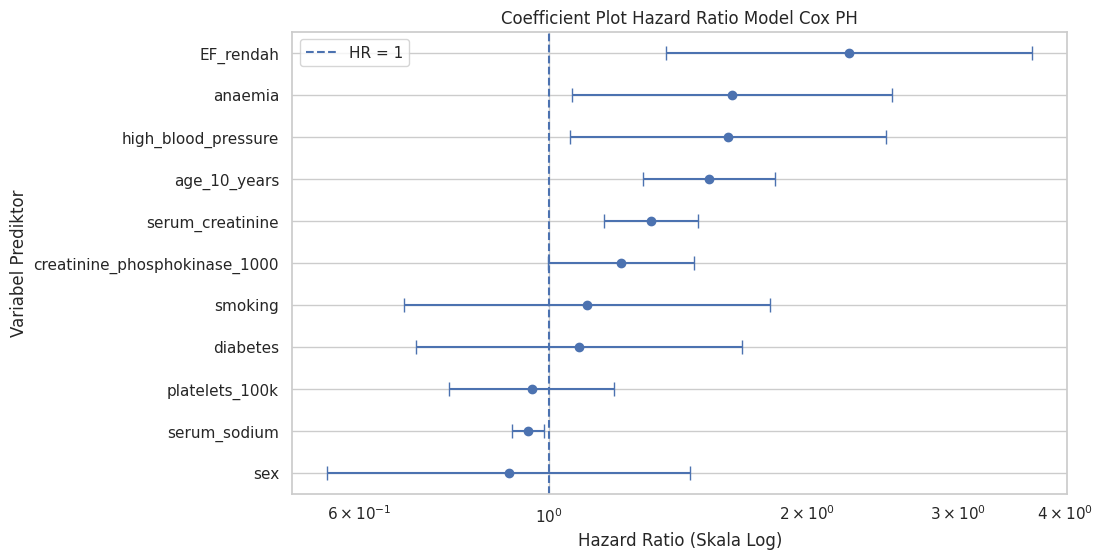

In [ ]:
plot_hr = hasil_cox_full.reset_index()
plot_hr = plot_hr.rename(columns={"covariate": "Variabel"})

# Urutkan berdasarkan Hazard Ratio agar mudah dibaca
plot_hr = plot_hr.sort_values("Hazard Ratio")

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=plot_hr["Hazard Ratio"],
    y=plot_hr["Variabel"],
    xerr=[
        plot_hr["Hazard Ratio"] - plot_hr["CI 95% Bawah"],
        plot_hr["CI 95% Atas"] - plot_hr["Hazard Ratio"]
    ],
    fmt="o",
    capsize=5
)

plt.axvline(x=1, linestyle="--", label="HR = 1")
plt.xscale("log")
plt.title("Coefficient Plot Hazard Ratio Model Cox PH")
plt.xlabel("Hazard Ratio (Skala Log)")
plt.ylabel("Variabel Prediktor")
plt.legend()
plt.grid(True)
plt.show()

## Uji Asumsi Cox Proportional Hazard


In [ ]:
# Uji asumsi proportional hazard
# Jika muncul peringatan pada variabel tertentu, berarti variabel tersebut berpotensi melanggar asumsi PH.
cph_full.check_assumptions(
    cox_df_lengkap,
    p_value_threshold=0.05,
    show_plots=False
)

Proportional hazard assumption looks okay.


[]